# Import Libraries


In [18]:
import os
import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report

import tensorflow as tf

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    Conv2D,
    MaxPooling2D,
    Flatten,
    Dense,
    Dropout
)

from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.utils import to_categorical

## Define Dataset Path

In [19]:
dataset_path = "images"

classes = ["normal", "scratch", "dent", "stain"]

image_size = 128

# Load Dataset


In [20]:
X = []
y = []

class_counts = {}

for label, class_name in enumerate(classes):

    folder_path = os.path.join(dataset_path, class_name)

    image_files = os.listdir(folder_path)

    class_counts[class_name] = len(image_files)

    for image_name in image_files:

        image_path = os.path.join(folder_path, image_name)

        image = cv2.imread(image_path)

        image = cv2.resize(image, (image_size, image_size))

        X.append(image)

        y.append(label)

print("Dataset Loaded Successfully")

Dataset Loaded Successfully


## # Task 1: Problem Identification

## Selected Problem Type: Image Classification

This dataset represents an Image Classification problem because each image belongs to only one category.

The dataset contains four classes:
- normal
- scratch
- dent
- stain

The objective of the model is to classify the entire image into one of these four categories.

This is not Object Detection because no bounding boxes are provided.

This is not Semantic Segmentation or Instance Segmentation because no pixel-level masks are available.

Therefore, Image Classification is the most appropriate problem type for this dataset.

# Dataset Exploration

In [21]:
print("Number of Classes:", len(classes))

print("\nImages Per Class:\n")

for class_name, count in class_counts.items():
    print(f"{class_name}: {count}")

Number of Classes: 4

Images Per Class:

normal: 120
scratch: 120
dent: 120
stain: 120


# Display Sample Images

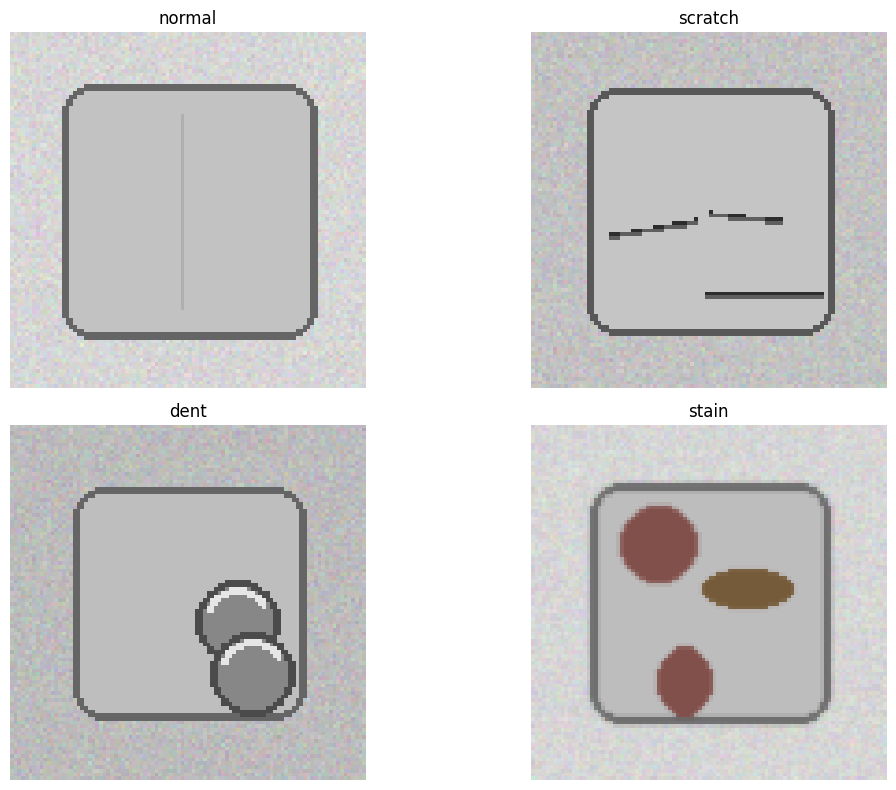

In [22]:
plt.figure(figsize=(12,8))

for i, class_name in enumerate(classes):

    folder_path = os.path.join(dataset_path, class_name)

    image_name = os.listdir(folder_path)[0]

    image_path = os.path.join(folder_path, image_name)

    image = cv2.imread(image_path)

    image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

    plt.subplot(2,2,i+1)

    plt.imshow(image)

    plt.title(class_name)

    plt.axis("off")

plt.tight_layout()

plt.show()

# Convert into NumPy Arrays

In [24]:
X = np.array(X)

y = np.array(y)

print("Image Data Shape:", X.shape)

print("Label Shape:", y.shape)

Image Data Shape: (480, 128, 128, 3)
Label Shape: (480,)


# Normalize Images

In [25]:
X = X / 255.0

# One-Hot Encoding

In [26]:
y = to_categorical(y, num_classes=4)

print("Encoded Labels Shape:", y.shape)

Encoded Labels Shape: (480, 4)


# Train-Test Split

In [27]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training Data Shape:", X_train.shape)

print("Testing Data Shape:", X_test.shape)

Training Data Shape: (384, 128, 128, 3)
Testing Data Shape: (96, 128, 128, 3)


# Data Augmentation

In [28]:
datagen = ImageDataGenerator(
    rotation_range=10,
    zoom_range=0.1,
    horizontal_flip=True
)

datagen.fit(X_train)

# CNN Model Creation

In [31]:
model = Sequential()

# First Convolution Layer
model.add(
    Conv2D(
        32,
        (3,3),
        activation='relu',
        input_shape=(128,128,3)
    )
)

# First Pooling Layer
model.add(MaxPooling2D(pool_size=(2,2)))

# Second Convolution Layer
model.add(
    Conv2D(
        64,
        (3,3),
        activation='relu'
    )
)

# Second Pooling Layer
model.add(MaxPooling2D(pool_size=(2,2)))

# Flatten Layer
model.add(Flatten())

# Dense Layer
model.add(Dense(128, activation='relu'))

# Dropout Layer
model.add(Dropout(0.5))

# Output Layer
model.add(Dense(4, activation='softmax'))

model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_4 (Conv2D)               │ (None, 126, 126, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 63, 63, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 61, 61, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 30, 30, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 57600)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 128)            │     7,372,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 4)              │           516 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 7,392,836 (28.20 MB)

 Trainable params: 7,392,836 (28.20 MB)

 Non-trainable params: 0 (0.00 B)

# Compile Model

In [33]:
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# Train Model

In [35]:
history = model.fit(
    datagen.flow(X_train, y_train, batch_size=32),
    epochs=15,
    validation_data=(X_test, y_test)
)

Epoch 1/15
12/12 ━━━━━━━━━━━━━━━━━━━━ 1s 82ms/step - accuracy: 0.7684 - loss: 0.7011 - val_accuracy: 0.8750 - val_loss: 0.5516
Epoch 2/15
12/12 ━━━━━━━━━━━━━━━━━━━━ 1s 83ms/step - accuracy: 0.7531 - loss: 0.6065 - val_accuracy: 0.8854 - val_loss: 0.4625
Epoch 3/15
12/12 ━━━━━━━━━━━━━━━━━━━━ 1s 83ms/step - accuracy: 0.7816 - loss: 0.5431 - val_accuracy: 0.7188 - val_loss: 0.6389
Epoch 4/15
12/12 ━━━━━━━━━━━━━━━━━━━━ 1s 84ms/step - accuracy: 0.7087 - loss: 0.8198 - val_accuracy: 0.7604 - val_loss: 0.6457
Epoch 5/15
12/12 ━━━━━━━━━━━━━━━━━━━━ 1s 84ms/step - accuracy: 0.7460 - loss: 0.6801 - val_accuracy: 0.7396 - val_loss: 0.7942
Epoch 6/15
12/12 ━━━━━━━━━━━━━━━━━━━━ 1s 84ms/step - accuracy: 0.7428 - loss: 0.7257 - val_accuracy: 0.7396 - val_loss: 0.4952
Epoch 7/15
12/12 ━━━━━━━━━━━━━━━━━━━━ 1s 85ms/step - accuracy: 0.7931 - loss: 0.4864 - val_accuracy: 0.9167 - val_loss: 0.4371
Epoch 8/15
12/12 ━━━━━━━━━━━━━━━━━━━━ 1s 87ms/step - accuracy: 0.8155 - loss: 0.5177 - val_accuracy: 0.7188 - v

# Accuracy & Loss Curves

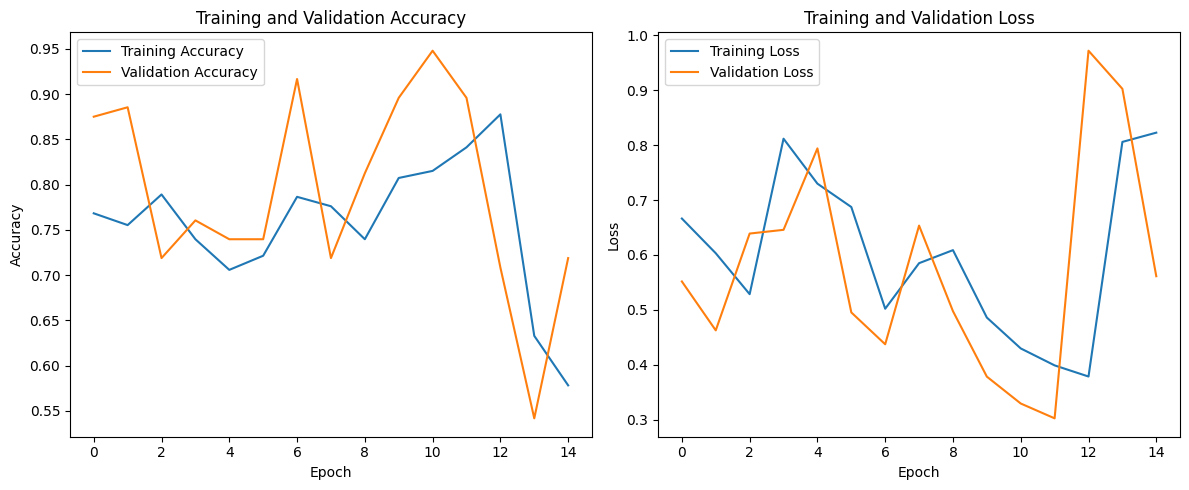

In [36]:
plt.figure(figsize=(12,5))

# Accuracy Graph
plt.subplot(1,2,1)

plt.plot(history.history['accuracy'], label='Training Accuracy')

plt.plot(history.history['val_accuracy'], label='Validation Accuracy')

plt.title("Training and Validation Accuracy")

plt.xlabel("Epoch")

plt.ylabel("Accuracy")

plt.legend()

# Loss Graph
plt.subplot(1,2,2)

plt.plot(history.history['loss'], label='Training Loss')

plt.plot(history.history['val_loss'], label='Validation Loss')

plt.title("Training and Validation Loss")

plt.xlabel("Epoch")

plt.ylabel("Loss")

plt.legend()

plt.tight_layout()

plt.savefig("results/accuracy_loss_curves.png")

plt.show()

# Model Evaluation

In [37]:
test_loss, test_accuracy = model.evaluate(X_test, y_test)

print("Test Accuracy:", test_accuracy)

print("Test Loss:", test_loss)

3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - accuracy: 0.6797 - loss: 0.5983
Test Accuracy: 0.71875
Test Loss: 0.5611600875854492


# Predictions

In [38]:
predictions = model.predict(X_test)

predicted_classes = np.argmax(predictions, axis=1)

true_classes = np.argmax(y_test, axis=1)

3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step


# Classification Report

In [39]:
print(classification_report(
    true_classes,
    predicted_classes,
    target_names=classes
))

              precision    recall  f1-score   support

      normal       0.54      0.88      0.67        24
     scratch       0.43      0.25      0.32        24
        dent       0.95      0.75      0.84        24
       stain       1.00      1.00      1.00        24

    accuracy                           0.72        96
   macro avg       0.73      0.72      0.70        96
weighted avg       0.73      0.72      0.70        96



# Confusion Matrix

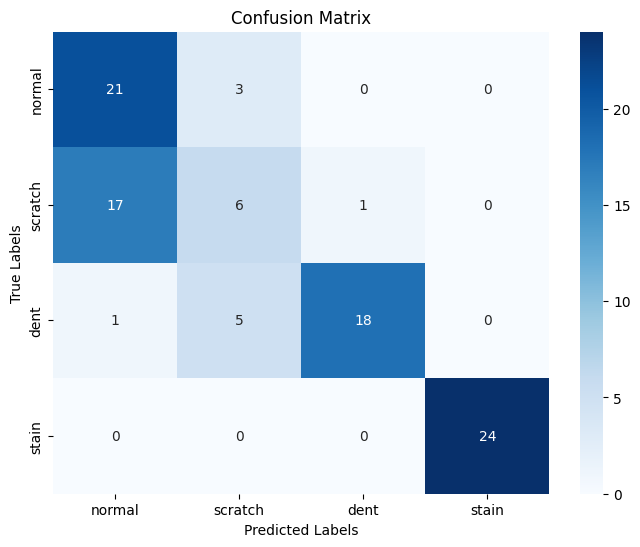

In [40]:
cm = confusion_matrix(true_classes, predicted_classes)

plt.figure(figsize=(8,6))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=classes,
    yticklabels=classes
)

plt.xlabel("Predicted Labels")

plt.ylabel("True Labels")

plt.title("Confusion Matrix")

plt.savefig("results/confusion_matrix.png")

plt.show()

# Sample Predictions

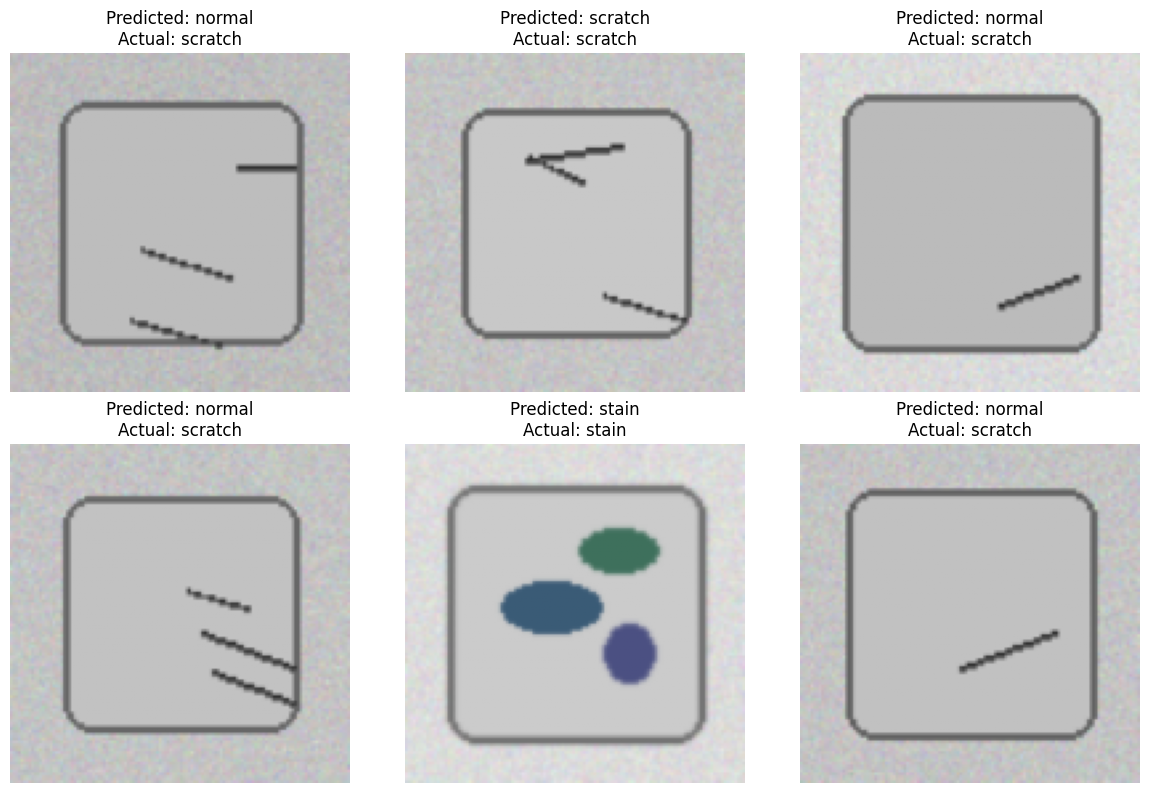

In [41]:
plt.figure(figsize=(12,8))

for i in range(6):

    plt.subplot(2,3,i+1)

    plt.imshow(X_test[i])

    plt.title(
        f"Predicted: {classes[predicted_classes[i]]}\nActual: {classes[true_classes[i]]}"
    )

    plt.axis("off")

plt.tight_layout()

plt.savefig("sample_predictions/prediction_outputs.png")

plt.show()

# Save Model

In [45]:
model.save("cnn_defect_classifier.keras")

print("CNN Model Saved Successfully")

CNN Model Saved Successfully
